# TP1 · Notebook 01 — Carga, control de calidad y EDA
Cuenca endorreica del Salar de Callacao (La Puna. Salta, Argentina).
Series: `nieve` (Landsat, mensual 1986–2025) · `savi` y `agua` (Sentinel-2, ~5 días, 2016–2025).

## 1. Entorno, localización de archivos y carga

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings, os, glob
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import ccf
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (13, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})

# ---------------- configuración ----------------
NOMBRE_CARPETA = 'DATASETS'
RUTA_DIRECTA   = '/content/drive/MyDrive/TP Analisis de Series Temporales/DATASETS'
ZONAS          = None            # None = todas las zonas (nivel cuenca)
VENTANA_COMUN  = ('2016-07-01', '2025-03-01')
PATRONES = {'nieve_1': '*sup_nieve*1*.csv', 'nieve_2': '*sup_nieve*2*.csv',
            'savi': '*savi*.csv', 'agua': '*agua*.csv'}
# -----------------------------------------------

try:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
except ImportError:
    pass

# Ruta directa; si falla, glob escalonado (evita recursión completa sobre Drive)
CARPETA_DATOS = RUTA_DIRECTA if os.path.isdir(RUTA_DIRECTA) else next(
    (h for raiz in ['/content/drive/MyDrive', '/content', '.'] for n in range(4)
     for h in glob.glob(os.path.join(raiz, *(['*'] * n), NOMBRE_CARPETA)) if os.path.isdir(h)), None)
assert CARPETA_DATOS, f'No se encontró la carpeta {NOMBRE_CARPETA}. Ajustar RUTA_DIRECTA.'

rutas = {k: sorted(glob.glob(os.path.join(CARPETA_DATOS, '**', p), recursive=True))[0]
         for k, p in PATRONES.items()}
CARPETA_SALIDA = os.path.join(CARPETA_DATOS.rsplit('/', 1)[0], 'OUTPUTS')
os.makedirs(CARPETA_SALIDA, exist_ok=True)
print('Datos:', CARPETA_DATOS, '\nSalida:', os.path.abspath(CARPETA_SALIDA))

# ---------------- parsers ----------------
# Los CSV vienen en UTF-8 con BOM: el encabezado queda como '\ufeff"id_zona"'.
MESES_ES = {'ene.': 1, 'feb.': 2, 'mar.': 3, 'abr.': 4, 'may.': 5, 'jun.': 6,
            'jul.': 7, 'ago.': 8, 'sep.': 9, 'oct.': 10, 'nov.': 11, 'dic.': 12}
MESES_ABR = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

def limpiar_columnas(df):
    df.columns = [c.replace('\ufeff', '').strip().strip('"') for c in df.columns]
    return df

def parsear_mes_es(texto):
    # '1986 ene.' -> Timestamp('1986-01-01'); NaT si no matchea (permite contar fallas)
    try:
        anio, mes = texto.strip().split()
        return pd.Timestamp(int(anio), MESES_ES[mes.lower()], 1)
    except (ValueError, KeyError):
        return pd.NaT

crudo = {k: limpiar_columnas(pd.read_csv(v)) for k, v in rutas.items()}
for k, df in crudo.items():
    print(f'{k:8s} filas={len(df):5d}  cols={list(df.columns)}')

Mounted at /content/drive
Datos: /content/drive/MyDrive/TP Analisis de Series Temporales/DATASETS 
Salida: /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS
nieve_1  filas= 2772  cols=['id_zona', 'sup_nieve', 'month']
nieve_2  filas= 3297  cols=['id_zona', 'sup_nieve', 'month']
savi     filas= 5712  cols=['id', 'date', 'savi', 'tipo', 'id_zona', 'mean_ndvi']
agua     filas= 3017  cols=['id_zona', 'date', 'sup_agua']


## 2. Control de calidad

**2.1** `nieve_1` vs `nieve_2`: se verifica que la segunda (nieve_2) contenga a la primera  (nieve_1) y se testea si los meses
recuperados (depuración por enmascaramiento de nubes) son sistemáticamente más nevados.

In [2]:
n1, n2 = crudo['nieve_1'].copy(), crudo['nieve_2'].copy()
a = n1.set_index(['id_zona', 'month'])['sup_nieve']
b = n2.set_index(['id_zona', 'month'])['sup_nieve']
comunes = a.index.intersection(b.index)

print(f'nieve_1 {n1.shape} | nieve_2 {n2.shape} | zonas: {sorted(n2.id_zona.unique())}')
print(f'(zona,mes) comunes={len(comunes)}  sólo_n2={len(b.index.difference(a.index))}  '
      f'sólo_n1={len(a.index.difference(b.index))}  '
      f'valores idénticos={np.allclose(a.loc[comunes].values, b.loc[comunes].values)}')

n2['fecha']   = n2['month'].map(parsear_mes_es)
n2['origen']  = np.where(n2['month'].isin(set(n1['month'])), 'común', 'recuperado')
n2['mes_cal'] = n2['fecha'].dt.month
print('Fechas no parseadas:', n2['fecha'].isna().sum())

# Mediana por mes calendario según origen (se controla por estacionalidad; mediana por asimetría)
comp = n2.pivot_table(index='mes_cal', columns='origen', values='sup_nieve', aggfunc='median')
comp['n_recuperados'] = n2[n2.origen == 'recuperado'].groupby('mes_cal').size()
comp['razón'] = comp['recuperado'] / comp['común']
comp.index = MESES_ABR
display(comp.round(2))
for e in ['común', 'recuperado']:
    s = n2.loc[n2.origen == e, 'sup_nieve']
    print(f'{e:11s} mediana={s.median():8.1f}  %ceros={(s == 0).mean() * 100:.1f}')

# Chequeo de artefactos: ¿los años dominados por meses recuperados quedan anómalos?
total_mensual = n2.groupby('fecha')['sup_nieve'].sum()
total_anual   = total_mensual.groupby(total_mensual.index.year).sum()
frac_recup    = n2.groupby(n2['fecha'].dt.year)['origen'].apply(lambda s: (s == 'recuperado').mean())
sosp = pd.DataFrame({'total_anual': total_anual.round(0),
                     '%_recuperados': (frac_recup * 100).round(0)})
sosp = sosp[sosp['%_recuperados'] >= 50]
sosp['puesto'] = [int((total_anual > total_anual.loc[y]).sum()) + 1 for y in sosp.index]
print(f'\nMediana del total anual: {total_anual.median():,.0f}  (puesto sobre {len(total_anual)} años)')
display(sosp)

nieve_1 (2772, 3) | nieve_2 (3297, 3) | zonas: ['ZC1', 'ZC2', 'ZC3', 'ZC4', 'ZS1', 'ZS2', 'ZS3']
(zona,mes) comunes=2772  sólo_n2=525  sólo_n1=0  valores idénticos=True
Fechas no parseadas: 0


origen,común,recuperado,n_recuperados,razón
Ene,25.83,49.96,42,1.93
Feb,26.01,44.73,49,1.72
Mar,30.69,58.98,56,1.92
Abr,40.03,103.03,56,2.57
May,147.29,363.41,56,2.47
Jun,665.08,1380.52,63,2.08
Jul,697.90,863.86,35,1.24
Ago,526.15,218.95,35,0.42
Sep,279.58,196.73,35,0.70
Oct,115.76,205.64,28,1.78


común       mediana=    78.6  %ceros=5.6
recuperado  mediana=   128.0  %ceros=10.1

Mediana del total anual: 107,009  (puesto sobre 40 años)


,total_anual,%_recuperados,puesto
fecha,,,
1987,79515.0,67.0,23
2003,64815.0,50.0,24
2012,79907.0,100.0,22


**2.2** SAVI: la columna `id` identifica dos polígonos por zona (no filas duplicadas).

**2.3** Cobertura temporal de cada fuente: define la frecuencia de trabajo y las dos ventanas.

tipo (SAVI): ['bs'] | polígonos por zona: {'ZC1': 2, 'ZC2': 2, 'ZC3': 2, 'ZC4': 2, 'ZS1': 2, 'ZS3': 2}
(id_zona, fecha) repetidos en SAVI: 2807 | mean_ndvi constante por polígono: True


,filas,zonas,fechas únicas,desde,hasta,gap mediano,gap máximo,nulos,% ceros
serie,,,,,,,,,
nieve,3297,7,471,1986-01-01,2025-03-01,31.0,31.0,0,6.3
savi,5712,6,496,2016-07-23,2025-03-28,5.0,40.0,0,0.0
agua,3017,7,431,2016-01-05,2025-03-20,5.0,100.0,0,13.4


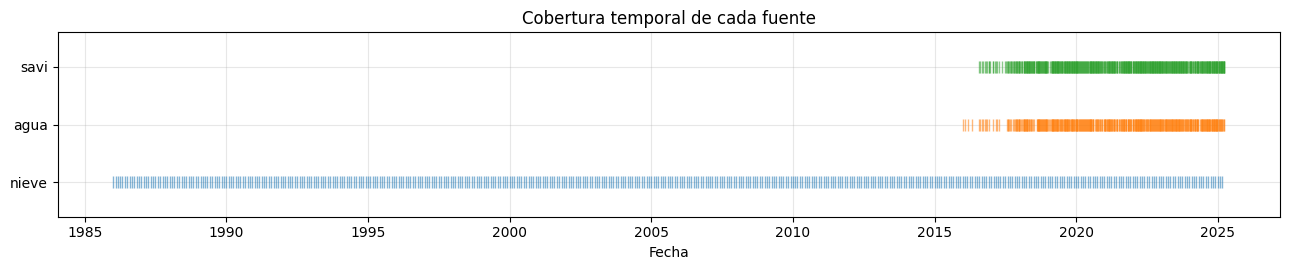

In [3]:
sv = crudo['savi'].copy(); sv['fecha'] = pd.to_datetime(sv['date'])
ag = crudo['agua'].copy(); ag['fecha'] = pd.to_datetime(ag['date'])

print("tipo (SAVI):", sv['tipo'].unique(),
      '| polígonos por zona:', sv.groupby('id_zona')['id'].nunique().to_dict())
print('(id_zona, fecha) repetidos en SAVI:', sv.duplicated(['id_zona', 'fecha']).sum(),
      '| mean_ndvi constante por polígono:', sv.groupby('id')['mean_ndvi'].nunique().eq(1).all())

resumen = []
for nombre, df, col in [('nieve', n2, 'sup_nieve'), ('savi', sv, 'savi'), ('agua', ag, 'sup_agua')]:
    gaps = pd.Series(sorted(df['fecha'].unique())).diff().dt.days.dropna()
    resumen.append({'serie': nombre, 'filas': len(df), 'zonas': df['id_zona'].nunique(),
                    'fechas únicas': df['fecha'].nunique(),
                    'desde': df['fecha'].min().date(), 'hasta': df['fecha'].max().date(),
                    'gap mediano': gaps.median(), 'gap máximo': gaps.max(),
                    'nulos': int(df[col].isna().sum()),
                    '% ceros': round(100 * (df[col] == 0).mean(), 1)})
display(pd.DataFrame(resumen).set_index('serie'))

fig, ax = plt.subplots(figsize=(13, 2.8))
for i, (nombre, df) in enumerate([('nieve', n2), ('agua', ag), ('savi', sv)]):
    f = pd.Series(sorted(df['fecha'].unique()))
    ax.plot(f, np.full(len(f), i), '|', markersize=9, alpha=0.55)
ax.set(yticks=range(3), ylim=(-0.6, 2.6), xlabel='Fecha', title='Cobertura temporal de cada fuente')
ax.set_yticklabels(['nieve', 'agua', 'savi'])
plt.tight_layout(); plt.show()

## 3. Construcción de las series mensuales

Agregación espacial: **suma** para las extensivas (`sup_nieve`, `sup_agua`), **promedio** para la intensiva
(`savi`). Agregación intra-mensual: **promedio** (el número de escenas por mes varía entre 2 y 8).
Dos ventanas: completa (471 meses, univariado de `nieve`) y común (105 meses, VAR).

Análisis de faltantes. Criterio para imputar: correlación lineal

nieve  1986-01 a 2025-03 | n=471 | NaN=0
savi   2016-07 a 2025-03 | n=105 | NaN=0
agua   2016-01 a 2025-03 | n=111 | NaN=4

Rango completo: 471 meses | ventana común: 105 meses
Faltantes en ventana común: {'nieve': 0, 'savi': 0, 'agua': 2}


,nieve,savi,agua
fecha,,,
2017-05-01,1172.957845,0.299949,NaN
2017-06-01,113408.266207,0.221106,NaN


Valores imputados:
fecha
2017-05-01    246.55
2017-06-01    277.07
Freq: MS


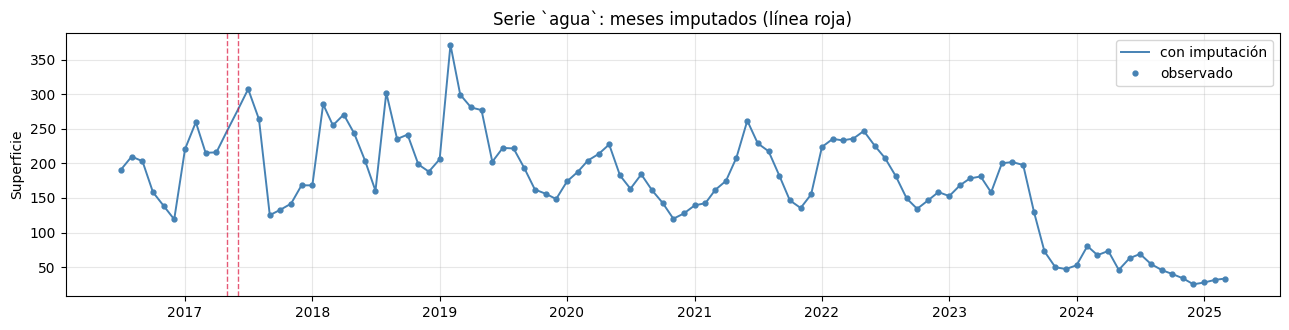

In [4]:
filtrar = lambda df: df if ZONAS is None else df[df['id_zona'].isin(ZONAS)]

# NIEVE: suma entre zonas (ya es mensual; 'MS' sólo reindexa al día 1)
s_nieve = (filtrar(n2).groupby('fecha')['sup_nieve'].sum()
           .resample('MS').sum().rename('nieve'))

# SAVI: promedio de polígonos -> de zonas -> de fechas dentro del mes
s_savi = (filtrar(sv).groupby(['fecha', 'id_zona', 'id'])['savi'].mean()
          .groupby(['fecha', 'id_zona']).mean()
          .groupby('fecha').mean()
          .resample('MS').mean().rename('savi'))

# AGUA: suma entre zonas por fecha, luego PROMEDIO mensual (no suma)
s_agua = (filtrar(ag).groupby('fecha')['sup_agua'].sum()
          .resample('MS').mean().rename('agua'))

# asfreq('MS') fuerza índice mensual continuo: ARIMA exige observaciones equiespaciadas
df_mensual = pd.concat([s_nieve, s_savi, s_agua], axis=1).asfreq('MS')
df_comun   = df_mensual.loc[VENTANA_COMUN[0]:VENTANA_COMUN[1]].copy()
faltantes  = df_comun[df_comun.isna().any(axis=1)]

for s in (s_nieve, s_savi, s_agua):
    print(f'{s.name:6s} {s.index.min():%Y-%m} a {s.index.max():%Y-%m} | n={len(s)} | NaN={s.isna().sum()}')
print(f'\nRango completo: {len(df_mensual)} meses | ventana común: {len(df_comun)} meses')
print('Faltantes en ventana común:', df_comun.isna().sum().to_dict())
display(faltantes)

# Interpolación lineal: 2 faltantes aislados de `agua` (1,9 % de la ventana)
df_comun_interp = df_comun.interpolate(method='linear', limit_direction='both')
print('Valores imputados:\n' + df_comun_interp.loc[faltantes.index, 'agua'].round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.plot(df_comun_interp.index, df_comun_interp['agua'], color='steelblue', lw=1.4, label='con imputación')
ax.plot(df_comun.index, df_comun['agua'], color='steelblue', lw=0, marker='o', ms=3.5, label='observado')
for f in faltantes.index:
    ax.axvline(f, color='crimson', ls='--', lw=1, alpha=0.7)
ax.set(title='Serie `agua`: meses imputados (línea roja)', ylabel='Superficie'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Análisis exploratorio

**4.1** Series originales, estadísticos descriptivos y asimetría.

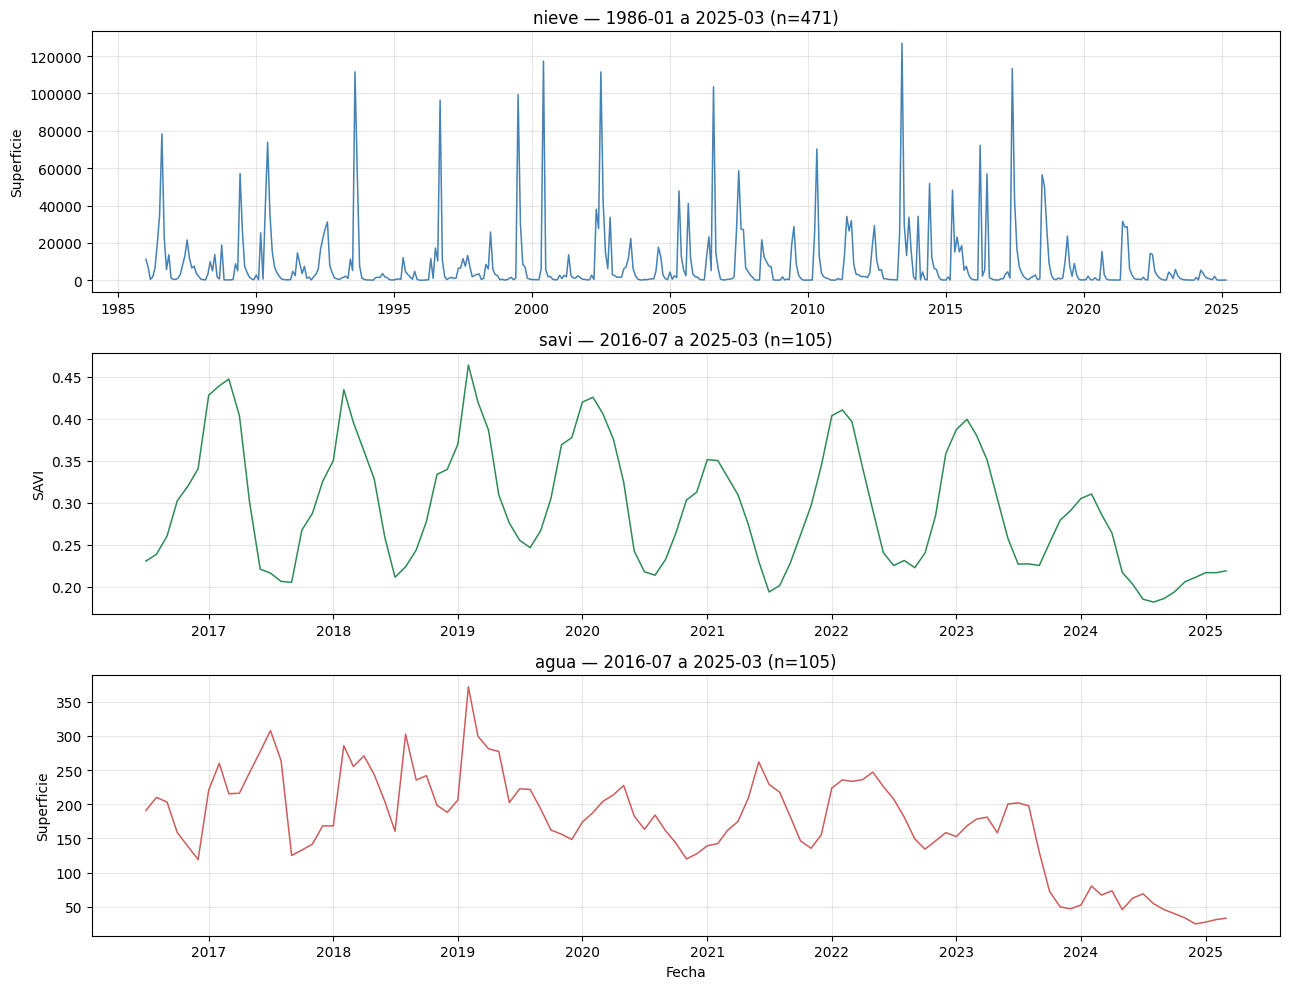

nieve — ventana completa 1986-2025


,count,mean,std,min,25%,50%,75%,max
nieve,471.0,8967.87,18221.13,50.26,460.85,1907.47,7771.27,126882.26


ventana común 2016-07 a 2025-03


,count,mean,std,min,25%,50%,75%,max
nieve,105.0,6431.5135,15469.8612,77.7485,290.5900,1027.8880,3840.3504,113408.2662
savi,105.0,0.2952,0.0736,0.1820,0.2281,0.2864,0.3502,0.4639
agua,105.0,173.2739,72.8509,25.0741,138.4205,181.1329,221.6600,371.6566


Asimetría (0 = simétrica, |skew| > 1 = cola marcada):
nieve    3.77
savi     0.43
agua    -0.23


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, (nombre, serie, color, ylab) in zip(axes, [
        ('nieve', s_nieve, 'steelblue', 'Superficie'),
        ('savi',  df_comun_interp['savi'], 'seagreen', 'SAVI'),
        ('agua',  df_comun_interp['agua'], 'indianred', 'Superficie')]):
    ax.plot(serie.index, serie.values, color=color, lw=1.1)
    ax.set(title=f'{nombre} — {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m} (n={len(serie)})',
           ylabel=ylab)
axes[2].set_xlabel('Fecha')
plt.tight_layout(); plt.show()

print('nieve — ventana completa 1986-2025');      display(s_nieve.describe().to_frame().T.round(2))
print('ventana común 2016-07 a 2025-03');         display(df_comun_interp.describe().T.round(4))
print('Asimetría (0 = simétrica, |skew| > 1 = cola marcada):')
print(pd.concat([s_nieve, df_comun_interp['savi'], df_comun_interp['agua']], axis=1).skew().round(2).to_string())

**4.2** Perfil estacional: boxplot por mes calendario y mapa de calor año × mes.

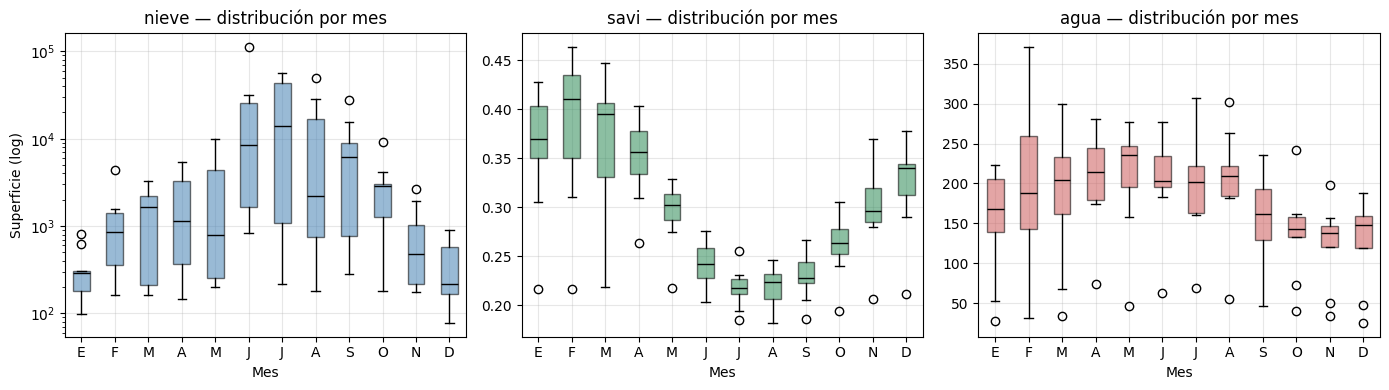

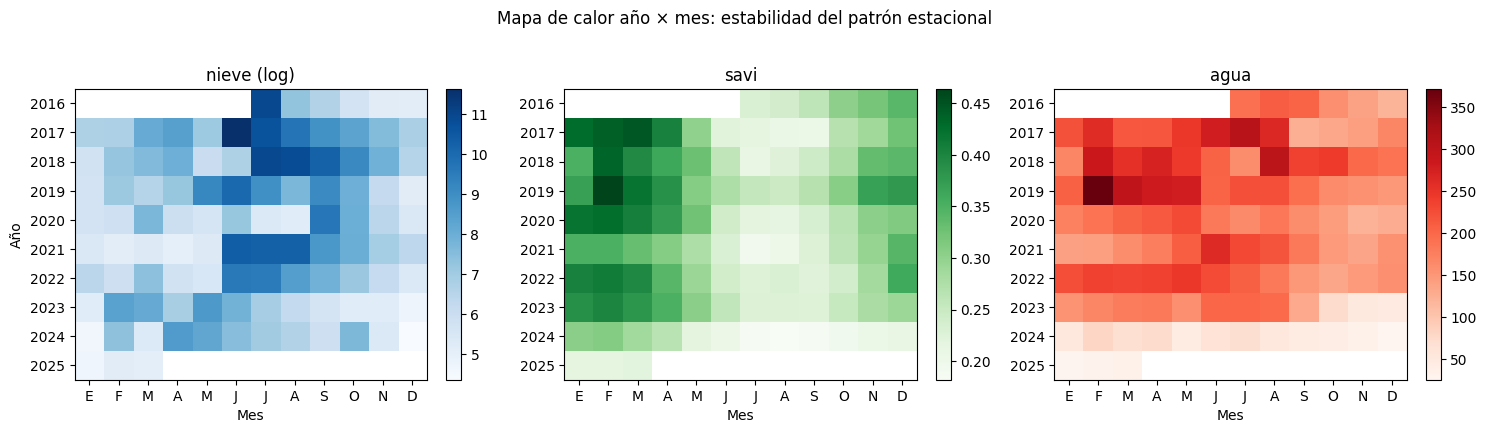

,nieve,savi,agua
Ene,326.104,0.359,151.665
Feb,1163.600,0.383,195.909
Mar,1511.121,0.365,183.100
Abr,1999.788,0.349,205.851
May,2746.205,0.294,206.762
Jun,23693.674,0.241,202.133
Jul,23210.318,0.218,194.699
Ago,11728.212,0.219,203.693
Sep,7712.222,0.230,158.281
Oct,2886.369,0.263,136.871


nieve  máximo: Jun  mínimo: Ene
savi   máximo: Feb  mínimo: Jul
agua   máximo: May  mínimo: Nov


In [6]:
series_plot = {'nieve': (s_nieve.loc['2016-07':], 'Blues',  'steelblue'),
               'savi' : (df_comun_interp['savi'], 'Greens', 'seagreen'),
               'agua' : (df_comun_interp['agua'], 'Reds',   'indianred')}
ini_mes = [m[0] for m in MESES_ABR]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nombre, (serie, _, color)) in zip(axes, series_plot.items()):
    bp = ax.boxplot([serie[serie.index.month == m].dropna().values for m in range(1, 13)],
                    patch_artist=True, medianprops=dict(color='black'))
    for caja in bp['boxes']:
        caja.set_facecolor(color); caja.set_alpha(0.55)
    ax.set_xticklabels(ini_mes); ax.set(title=f'{nombre} — distribución por mes', xlabel='Mes')
axes[0].set_yscale('log'); axes[0].set_ylabel('Superficie (log)')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nombre, (serie, cmap, _)) in zip(axes, series_plot.items()):
    piv = (serie.to_frame('v').assign(anio=lambda d: d.index.year, mes=lambda d: d.index.month)
                .pivot_table(index='anio', columns='mes', values='v'))
    val = np.log1p(piv.values) if nombre == 'nieve' else piv.values
    im = ax.imshow(val, aspect='auto', cmap=cmap,
                   extent=[0.5, 12.5, piv.index.max() + 0.5, piv.index.min() - 0.5])
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(ini_mes); ax.set_yticks(piv.index)
    ax.set(title=nombre + (' (log)' if nombre == 'nieve' else ''), xlabel='Mes'); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel('Año')
plt.suptitle('Mapa de calor año × mes: estabilidad del patrón estacional', y=1.02)
plt.tight_layout(); plt.show()

perfil = df_comun_interp.assign(mes=df_comun_interp.index.month).groupby('mes').mean()
perfil.index = MESES_ABR
display(perfil.round(3))
for c in perfil.columns:
    print(f'{c:6s} máximo: {perfil[c].idxmax():4s} mínimo: {perfil[c].idxmin()}')

**4.3** Descomposición STL (`robust=True`, período 12) y fuerza de tendencia/estacionalidad
(Wang, Smith & Hyndman, 2006). `nieve` se descompone en escala logarítmica.

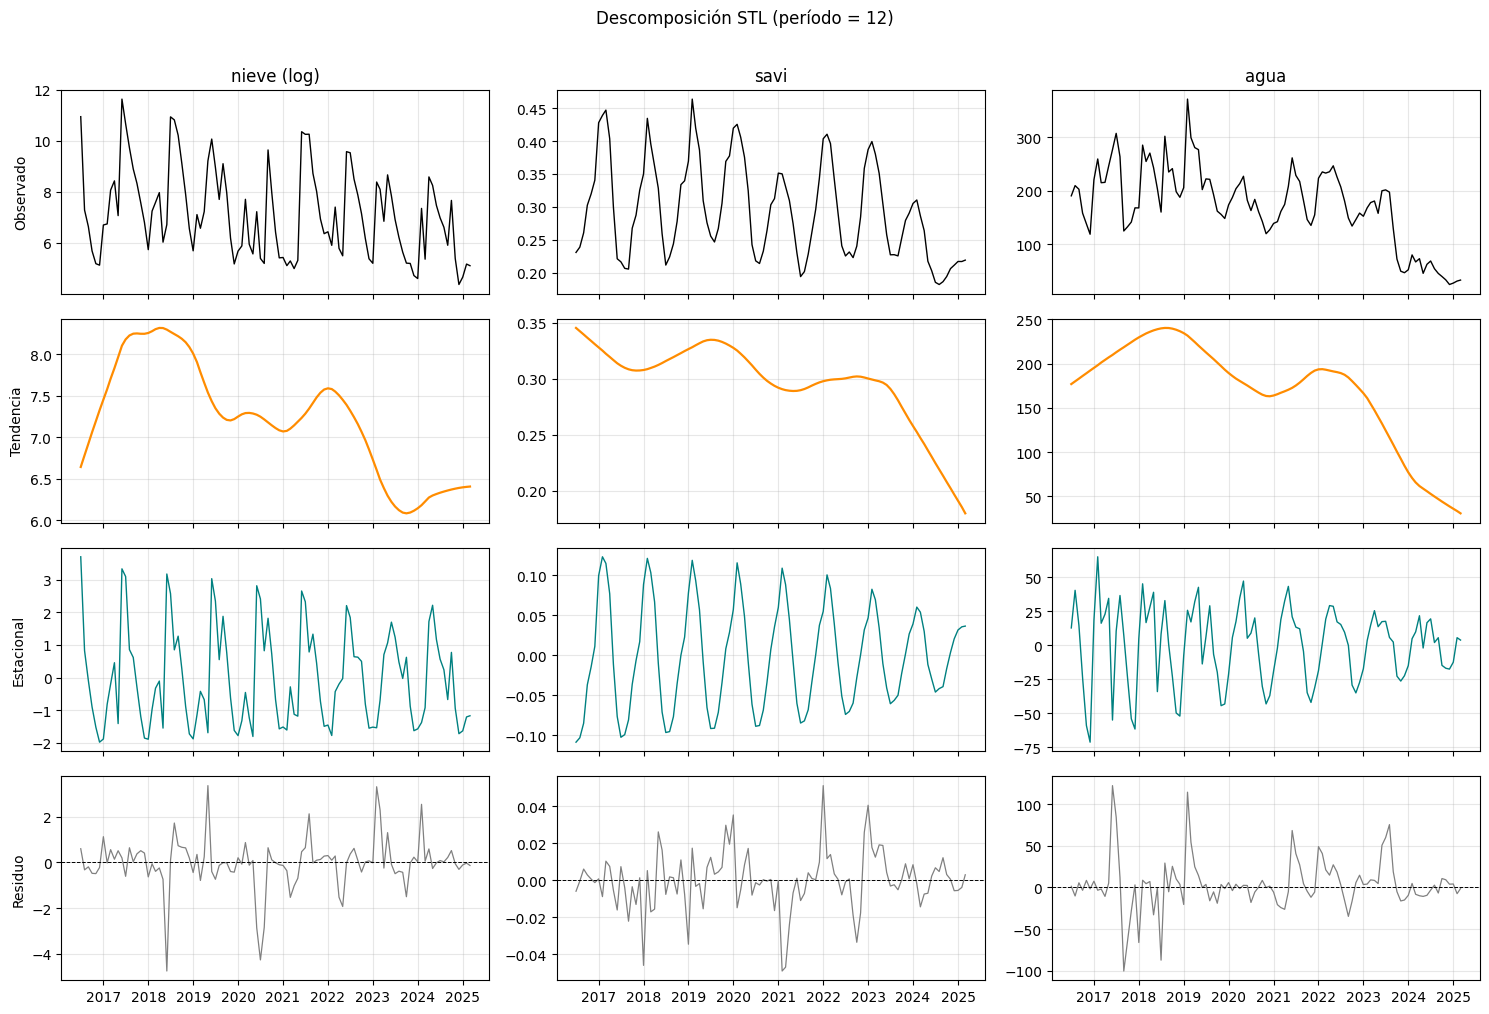

,fuerza_tendencia,fuerza_estacional
serie,,
nieve,0.228,0.538
savi,0.852,0.943
agua,0.781,0.470


Escala 0–1; > 0.6 indica componente fuerte.


In [7]:
componentes = {}
fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex='col')
for j, (nombre, serie) in enumerate([('nieve', np.log1p(s_nieve.loc['2016-07':])),
                                     ('savi',  df_comun_interp['savi']),
                                     ('agua',  df_comun_interp['agua'])]):
    stl = STL(serie.dropna(), period=12, robust=True).fit()
    componentes[nombre] = stl
    axes[0, j].plot(serie.index, serie.values, lw=1, color='black')
    axes[0, j].set_title(nombre + (' (log)' if nombre == 'nieve' else ''))
    axes[1, j].plot(stl.trend, lw=1.6, color='darkorange')
    axes[2, j].plot(stl.seasonal, lw=1, color='teal')
    axes[3, j].plot(stl.resid, lw=0.9, color='grey')
    axes[3, j].axhline(0, color='black', lw=0.7, ls='--')
for i, lab in enumerate(['Observado', 'Tendencia', 'Estacional', 'Residuo']):
    axes[i, 0].set_ylabel(lab)
plt.suptitle('Descomposición STL (período = 12)', y=1.01)
plt.tight_layout(); plt.show()

fuerza = pd.DataFrame([{'serie': k,
                        'fuerza_tendencia': max(0, 1 - v.resid.var() / (v.trend + v.resid).var()),
                        'fuerza_estacional': max(0, 1 - v.resid.var() / (v.seasonal + v.resid).var())}
                       for k, v in componentes.items()]).set_index('serie')
display(fuerza.round(3))
print('Escala 0–1; > 0.6 indica componente fuerte.')

**4.4** Estabilidad de la varianza: gráfico media–desvío por bloques anuales, CV y asimetría.

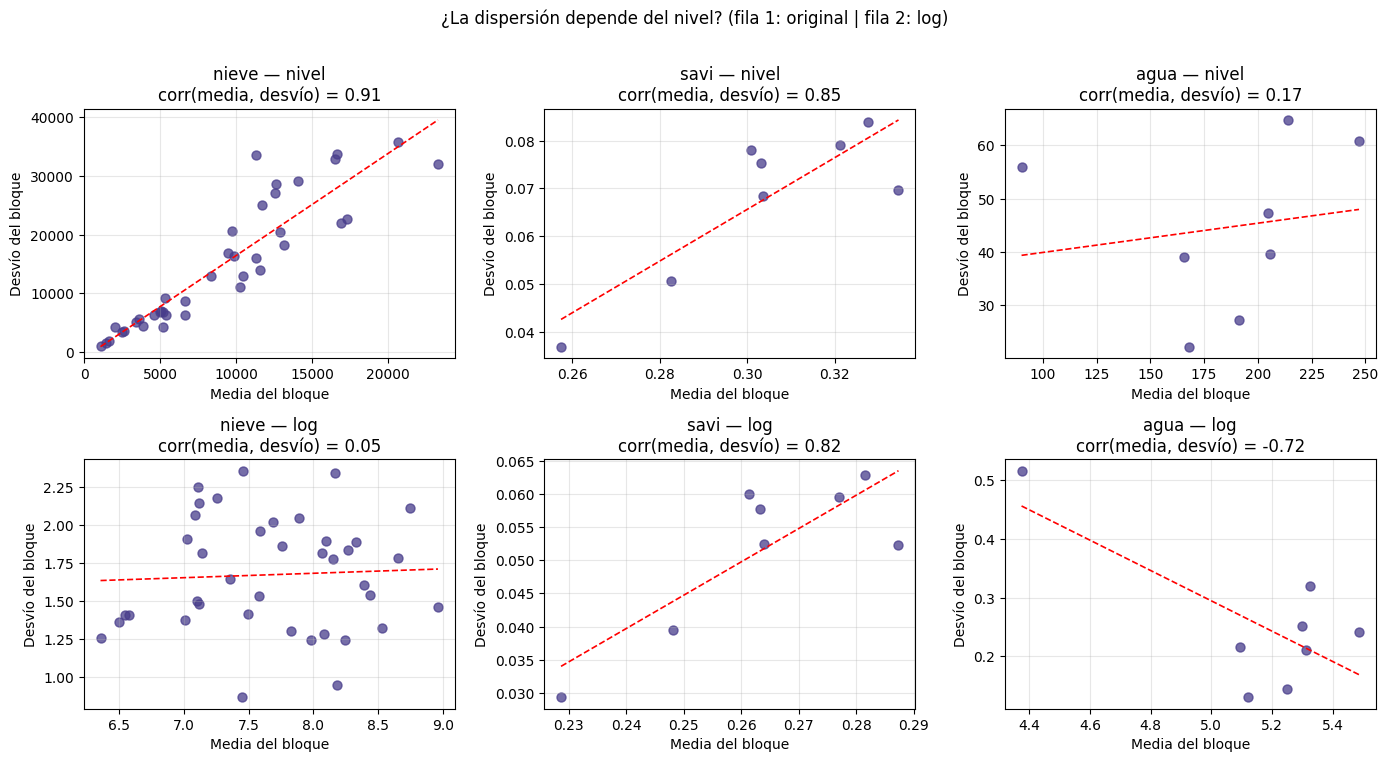

,CV nivel,CV log,skew nivel,skew log
serie,,,,
nieve,2.032,0.232,3.765,0.218
savi,0.249,0.219,0.427,0.352
agua,0.420,0.116,-0.231,-1.411


In [8]:
def media_desvio(serie, titulo, ax, bloque=12):
    s = serie.dropna(); nb = len(s) // bloque
    m = [s.iloc[i*bloque:(i+1)*bloque].mean() for i in range(nb)]
    d = [s.iloc[i*bloque:(i+1)*bloque].std()  for i in range(nb)]
    ax.scatter(m, d, s=42, alpha=0.75, color='darkslateblue')
    if nb > 2:
        p, o = np.polyfit(m, d, 1)
        xs = np.linspace(min(m), max(m), 50)
        ax.plot(xs, o + p * xs, 'r--', lw=1.2)
        titulo += f'\ncorr(media, desvío) = {np.corrcoef(m, d)[0, 1]:.2f}'
    ax.set(title=titulo, xlabel='Media del bloque', ylabel='Desvío del bloque')

SERIES = [('nieve', s_nieve), ('savi', df_comun_interp['savi']), ('agua', df_comun_interp['agua'])]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for j, (nombre, serie) in enumerate(SERIES):
    media_desvio(serie,           f'{nombre} — nivel', axes[0, j])
    media_desvio(np.log1p(serie), f'{nombre} — log',   axes[1, j])
plt.suptitle('¿La dispersión depende del nivel? (fila 1: original | fila 2: log)', y=1.01)
plt.tight_layout(); plt.show()

# log1p porque `nieve` contiene ceros
display(pd.DataFrame([{'serie': n, 'CV nivel': s.dropna().std() / s.dropna().mean(),
                       'CV log': np.log1p(s.dropna()).std() / np.log1p(s.dropna()).mean(),
                       'skew nivel': s.dropna().skew(), 'skew log': np.log1p(s.dropna()).skew()}
                      for n, s in SERIES]).set_index('serie').round(3))

**4.5** Tendencia de largo plazo: OLS y tau de Kendall (Mann-Kendall), más media móvil centrada de 12 meses.

,primeros 12m,últimos 12m,variación %,pendiente/mes,p-valor OLS,tau Kendall,p-valor MK
serie,,,,,,,
nieve,15319.2206,1333.4359,-91.2957,-139.1098,0.0047,-0.2187,0.0009
savi,0.3277,0.2085,-36.3546,-0.0008,0.0006,-0.2300,0.0005
agua,204.6107,45.2335,-77.8929,-1.5141,0.0000,-0.4179,0.0000


Ventana: 2016-07 a 2025-03.


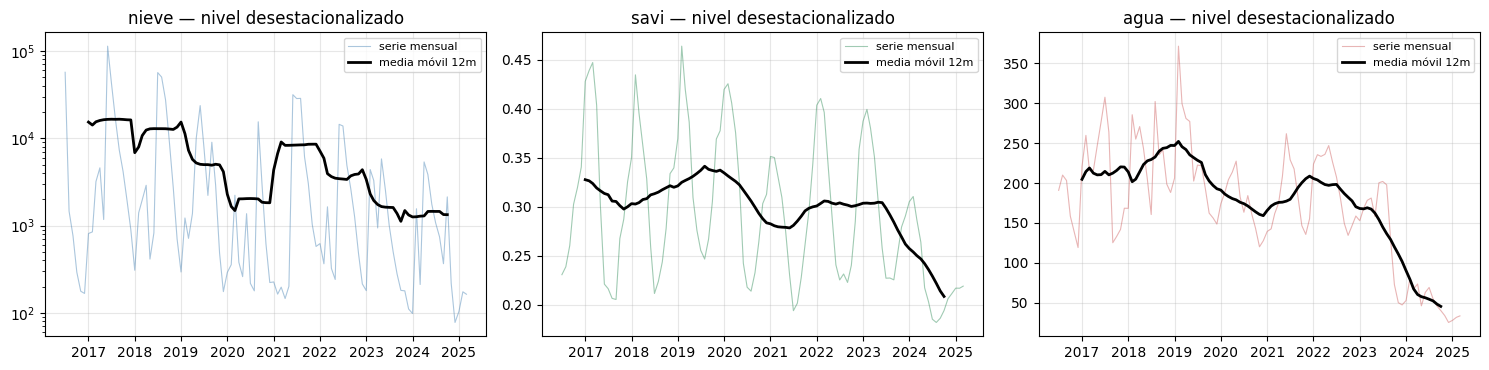

In [9]:
SERIES_COMUN = [('nieve', s_nieve.loc['2016-07':], 'steelblue'),
                ('savi',  df_comun_interp['savi'], 'seagreen'),
                ('agua',  df_comun_interp['agua'], 'indianred')]

filas = []
for nombre, serie, _ in SERIES_COMUN:
    s = serie.dropna(); x = np.arange(len(s))
    lr = stats.linregress(x, s.values)
    tau, p_tau = stats.kendalltau(x, s.values)
    filas.append({'serie': nombre, 'primeros 12m': s.iloc[:12].mean(), 'últimos 12m': s.iloc[-12:].mean(),
                  'variación %': 100 * (s.iloc[-12:].mean() / s.iloc[:12].mean() - 1),
                  'pendiente/mes': lr.slope, 'p-valor OLS': lr.pvalue,
                  'tau Kendall': tau, 'p-valor MK': p_tau})
display(pd.DataFrame(filas).set_index('serie').round(4))
print('Ventana: 2016-07 a 2025-03.')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (nombre, serie, color) in zip(axes, SERIES_COMUN):
    s = serie.dropna()
    ax.plot(s.index, s.values, color=color, lw=0.8, alpha=0.45, label='serie mensual')
    ax.plot(s.rolling(12, center=True).mean(), color='black', lw=2, label='media móvil 12m')
    ax.set_title(f'{nombre} — nivel desestacionalizado'); ax.legend(fontsize=8)
    if nombre == 'nieve':
        ax.set_yscale('log')
plt.tight_layout(); plt.show()

**4.6** Estructura de dependencia: matriz de correlación en nivel vs. desestacionalizada (STL) y
función de correlación cruzada. Insumo para justificar el VAR de los puntos 10 y 11.

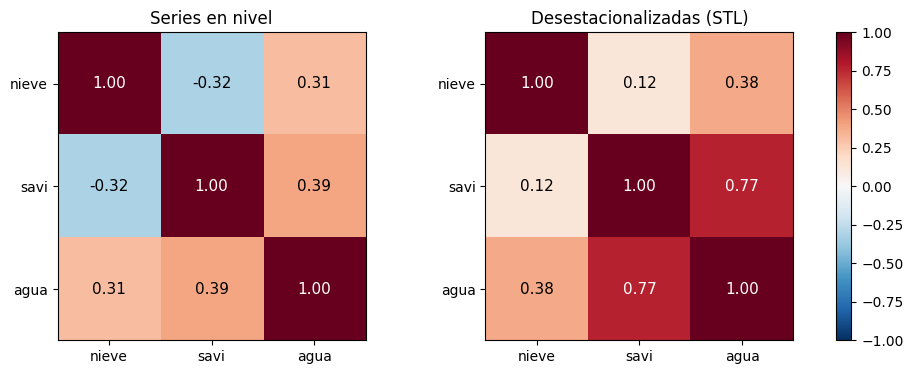

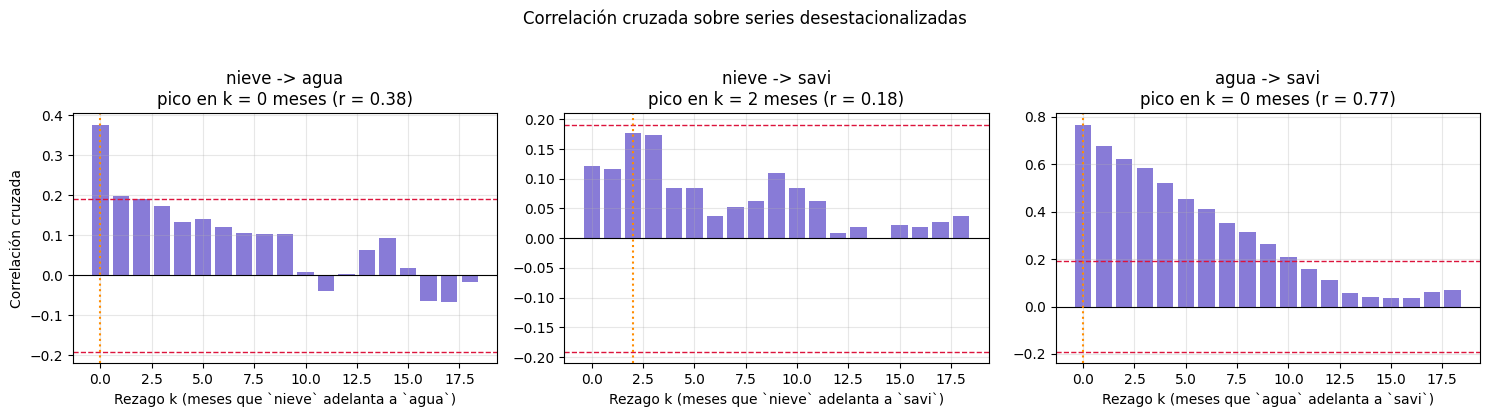

In [10]:
# Desestacionalizar = tendencia + residuo (se descarta el componente estacional)
df_desest = df_comun_interp.copy()
for c in df_desest.columns:
    stl = STL(df_desest[c], period=12, robust=True).fit()
    df_desest[c] = stl.trend + stl.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (m, titulo) in zip(axes, [(df_comun_interp.corr(), 'Series en nivel'),
                                  (df_desest.corr(), 'Desestacionalizadas (STL)')]):
    im = ax.imshow(m, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(m))); ax.set_xticklabels(m.columns)
    ax.set_yticks(range(len(m))); ax.set_yticklabels(m.columns)
    ax.grid(False); ax.set_title(titulo)
    for i in range(len(m)):
        for j in range(len(m)):
            ax.text(j, i, f'{m.iloc[i, j]:.2f}', ha='center', va='center', fontsize=11,
                    color='white' if abs(m.iloc[i, j]) > 0.55 else 'black')
plt.colorbar(im, ax=axes, fraction=0.03); plt.show()

MAX_LAG = 18
Z = (df_desest - df_desest.mean()) / df_desest.std()
banda = 1.96 / np.sqrt(len(Z))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [('nieve', 'agua'), ('nieve', 'savi'), ('agua', 'savi')]):
    v = ccf(Z[x].values, Z[y].values, adjusted=False)[:MAX_LAG + 1]   # ccf(a,b)[k] = corr(a_t, b_{t+k})
    ax.bar(range(len(v)), v, color='slateblue', alpha=0.8)
    ax.axhline(banda, color='crimson', ls='--', lw=1); ax.axhline(-banda, color='crimson', ls='--', lw=1)
    ax.axhline(0, color='black', lw=0.8)
    k = int(np.argmax(np.abs(v))); ax.axvline(k, color='darkorange', ls=':', lw=1.5)
    ax.set(title=f'{x} -> {y}\npico en k = {k} meses (r = {v[k]:.2f})',
           xlabel=f'Rezago k (meses que `{x}` adelanta a `{y}`)')
axes[0].set_ylabel('Correlación cruzada')
plt.suptitle('Correlación cruzada sobre series desestacionalizadas', y=1.03)
plt.tight_layout(); plt.show()

## 5. Exportación

`series_mensuales_completo.csv` (rango completo, sin imputar) y `series_mensuales_comun.csv`
(ventana común, imputada). Insumos del Notebook 02.

In [11]:
for nombre, df in [('01_series_mensuales_completo.csv', df_mensual),
                   ('01_series_mensuales_comun.csv', df_comun_interp)]:
    ruta = os.path.join(CARPETA_SALIDA, nombre)
    df.to_csv(ruta)
    print(f'{nombre}  ({os.path.getsize(ruta)/1024:.1f} KB)  ->  {os.path.abspath(ruta)}')

display(df_comun_interp.head(3)); display(df_comun_interp.tail(3))

01_series_mensuales_completo.csv  (18.2 KB)  ->  /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/01_series_mensuales_completo.csv
01_series_mensuales_comun.csv  (7.0 KB)  ->  /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/01_series_mensuales_comun.csv


,nieve,savi,agua
fecha,,,
2016-07-01,56953.504544,0.230735,190.833894
2016-08-01,1460.681208,0.238835,209.943714
2016-09-01,761.952652,0.260540,203.150952


,nieve,savi,agua
fecha,,,
2025-01-01,104.187747,0.216995,27.697987
2025-02-01,174.458688,0.216942,31.490203
2025-03-01,163.698321,0.219061,33.324719
